# Kidney Disease (CKD) Prediction
### Fixed notebook — run cells top to bottom, in order

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print('All imports OK')

All imports OK


In [2]:
# ── Cell 2: Feature list ──────────────────────────────────────
# Defined globally so every cell below can use it
FEATURES = [
    'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine',
    'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume',
    'white_blood_cell_count', 'red_blood_cell_count',
    'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
    'appetite', 'pedal_edema', 'anemia'
]
print(f'Feature count: {len(FEATURES)}')

Feature count: 24


In [3]:
# ── Cell 3: Load & clean function ─────────────────────────────
def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f'Raw shape: {df.shape}')

    # Strip tab/space noise from target BEFORE mapping
    # Without this, 'ckd\t' (2 rows) silently becomes NaN
    df['classification'] = df['classification'].str.strip()

    # Rename short UCI column names to readable full names
    df.rename(columns={
        'bp': 'blood_pressure',   'sg': 'specific_gravity',
        'al': 'albumin',          'su': 'sugar',
        'rbc': 'red_blood_cells', 'pc': 'pus_cell',
        'pcc': 'pus_cell_clumps', 'ba': 'bacteria',
        'bgr': 'blood_glucose_random', 'bu': 'blood_urea',
        'sc': 'serum_creatinine', 'sod': 'sodium',
        'pot': 'potassium',       'hemo': 'haemoglobin',
        'pcv': 'packed_cell_volume',
        'wc': 'white_blood_cell_count',
        'rc': 'red_blood_cell_count',
        'htn': 'hypertension',    'dm': 'diabetes_mellitus',
        'cad': 'coronary_artery_disease', 'appet': 'appetite',
        'pe': 'pedal_edema',      'ane': 'anemia',
    }, inplace=True)

    # Strip tab/space pollution from categorical columns
    # dm had '\t yes', ' yes', '\tno' — map() is exact match so these
    # would silently become NaN without strip()
    cat_cols = [
        'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
        'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
        'appetite', 'pedal_edema', 'anemia'
    ]
    for col in cat_cols:
        df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan})

    # pcv / wc / rc were stored as strings like '44', '\t?'
    # errors='coerce' converts '\t?' → NaN safely
    for col in ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

    # Encode yes/no columns to 1/0
    for col in ['hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'pedal_edema', 'anemia']:
        df[col] = df[col].map({'yes': 1, 'no': 0})

    df['red_blood_cells']   = df['red_blood_cells'].map({'normal': 1, 'abnormal': 0})
    df['pus_cell']          = df['pus_cell'].map({'normal': 1, 'abnormal': 0})
    df['pus_cell_clumps']   = df['pus_cell_clumps'].map({'present': 1, 'notpresent': 0})
    df['bacteria']          = df['bacteria'].map({'present': 1, 'notpresent': 0})
    df['appetite']          = df['appetite'].map({'good': 1, 'poor': 0})

    # Target column
    df['target'] = df['classification'].map({'ckd': 1, 'notckd': 0})
    df.drop(columns=['classification', 'id'], inplace=True, errors='ignore')

    print(f'Target NaN after mapping: {df["target"].isna().sum()}')
    return df

print('load_and_clean defined')

load_and_clean defined


In [5]:
# ── Cell 4: Run the cleaner — assign result to df ─────────────
# FIX: update this path to wherever YOUR csv lives
CSV_PATH = '/home/chinmaya/Desktop/coding/aiagent/health_care/data sets/kidney/kidney_disease.csv'

df = load_and_clean(CSV_PATH)

# Fill missing values using median per class (class-aware imputation)
# This is better than global median — CKD patients' bad values
# should not be filled with healthy-patient medians
numeric_cols = df[FEATURES].select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    for cls in [0, 1]:
        mask = df['target'] == cls
        median_val = df.loc[mask, col].median()
        df.loc[mask & df[col].isna(), col] = median_val
df[FEATURES] = df[FEATURES].fillna(df[FEATURES].median())  # safety net

print(f'Remaining NaN: {df[FEATURES].isnull().sum().sum()}')
print(f'Final shape: {df.shape}')
df.head(3)

Raw shape: (400, 26)
Target NaN after mapping: 0
Remaining NaN: 0
Final shape: (400, 25)


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.02,1.0,0.0,1.0,1.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.02,4.0,0.0,1.0,1.0,0.0,0.0,143.5,...,38.0,6000.0,3.9,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.01,2.0,3.0,1.0,1.0,0.0,0.0,423.0,...,31.0,7500.0,3.9,0.0,1.0,0.0,0.0,0.0,1.0,1


In [6]:
# ── Cell 5: Train & evaluate ──────────────────────────────────
X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_name, best_pipeline, best_auc = None, None, 0

print('── Cross-Validation (5-fold ROC-AUC) ──')
for name, clf in candidates.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    mean_auc = scores.mean()
    print(f'  {name:<25}  AUC = {mean_auc:.4f} ± {scores.std():.4f}')
    if mean_auc > best_auc:
        best_auc      = mean_auc
        best_name     = name
        best_pipeline = pipe

print(f'\nBest model: {best_name} (AUC = {best_auc:.4f})')

# Calibrate for reliable confidence scores
calibrated_model = CalibratedClassifierCV(best_pipeline, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

# FIX: capture the trained model into a variable named 'model'
# Your original notebook never did this — that's why 'model' was not defined
model = calibrated_model

print('model is now saved in memory as the variable: model')

── Cross-Validation (5-fold ROC-AUC) ──
  Logistic Regression        AUC = 1.0000 ± 0.0000
  Random Forest              AUC = 1.0000 ± 0.0000
  Gradient Boosting          AUC = 0.9873 ± 0.0249

Best model: Logistic Regression (AUC = 1.0000)
model is now saved in memory as the variable: model


Accuracy : 0.9875
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

      No CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



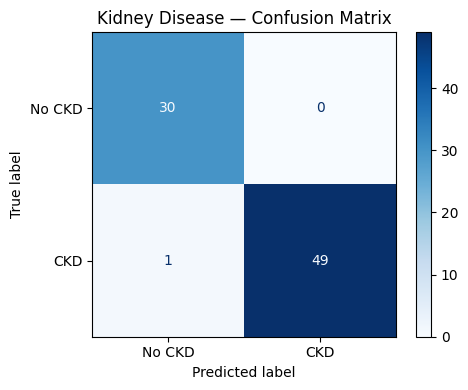

In [7]:
# ── Cell 6: Evaluate on test set ──────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No CKD', 'CKD']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No CKD', 'CKD'], cmap='Blues', ax=ax
)
ax.set_title('Kidney Disease — Confusion Matrix')
plt.tight_layout()
plt.show()

In [8]:
# ── Cell 7: Feature importance ────────────────────────────────
def plot_feature_importance(calibrated_model):
    # This function does NOT return the model — it only plots.
    # FIX: your original code did model=plot_feature_importance(...)
    # which set model = None (the return value of a void function)
    try:
        base = calibrated_model.calibrated_classifiers_[0].estimator
        clf  = base.named_steps['clf']
        fi   = clf.feature_importances_
        fi_df = pd.DataFrame({'feature': FEATURES, 'importance': fi})
        fi_df = fi_df.sort_values('importance', ascending=True).tail(15)

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
        ax.set_title('Kidney Disease — Feature Importance')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

        print('\nTop 5 Features:')
        print(fi_df.tail(5)[['feature', 'importance']].to_string(index=False))

    except AttributeError:
        print('Feature importance not available for Logistic Regression.')
        print('Logistic Regression won on AUC — that is fine.')

# FIX: call the function directly. Do NOT write model = plot_feature_importance(...)
# because the function returns None, which would overwrite your trained model!
plot_feature_importance(model)

Feature importance not available for Logistic Regression.
Logistic Regression won on AUC — that is fine.


In [9]:
# ── Cell 8: Save model ────────────────────────────────────────
# FIX: feature_list was never defined in original notebook
# Simply assign FEATURES to feature_list before calling save_model
feature_list = FEATURES

os.makedirs('models', exist_ok=True)
joblib.dump(model,        'models/kidney_model.pkl')
joblib.dump(feature_list, 'models/kidney_features.pkl')
print('Saved: models/kidney_model.pkl')
print('Saved: models/kidney_features.pkl')

Saved: models/kidney_model.pkl
Saved: models/kidney_features.pkl


In [ ]:
# ── Cell 9: Predict function ──────────────────────────────────
def predict_kidney_disease(model, patient_data: dict) -> dict:
    """
    patient_data is a PARAMETER — it only exists inside this function.
    When you call this function, you must pass a real dictionary as the argument.
    See Cell 10 below for correct usage.
    """
    defaults = {
        'age': 40, 'blood_pressure': 80, 'specific_gravity': 1.020,
        'albumin': 0, 'sugar': 0, 'red_blood_cells': 1, 'pus_cell': 1,
        'pus_cell_clumps': 0, 'bacteria': 0, 'blood_glucose_random': 100,
        'blood_urea': 25, 'serum_creatinine': 1.0, 'sodium': 140,
        'potassium': 4.5, 'haemoglobin': 13.5, 'packed_cell_volume': 44,
        'white_blood_cell_count': 7000, 'red_blood_cell_count': 4.5,
        'hypertension': 0, 'diabetes_mellitus': 0,
        'coronary_artery_disease': 0, 'appetite': 1,
        'pedal_edema': 0, 'anemia': 0
    }
    row = {f: patient_data.get(f, defaults[f]) for f in FEATURES}
    X   = pd.DataFrame([row])[FEATURES]

    prob = float(model.predict_proba(X)[0][1])
    prob = round(prob, 4)

    if prob >= 0.70:
        risk = 'High'
    elif prob >= 0.40:
        risk = 'Moderate'
    else:
        risk = 'Low'

    return {
        'disease':     'Kidney Disease',
        'probability': prob,
        'confidence':  f'{prob * 100:.1f}%',
        'risk_level':  risk
    }

print('predict_kidney_disease defined')

In [ ]:
# ── Cell 10: Test predictions ─────────────────────────────────
# FIX: You must pass a real dictionary, NOT the parameter name 'patient_data'
# 'patient_data' inside the function definition is just a label —
# it does not exist as a variable in your notebook's global scope.

# Test 1: a clearly sick patient
sick_patient = {
    'age': 65, 'blood_pressure': 90, 'specific_gravity': 1.010,
    'albumin': 4, 'sugar': 2, 'red_blood_cells': 0, 'pus_cell': 0,
    'pus_cell_clumps': 1, 'bacteria': 1, 'blood_glucose_random': 200,
    'blood_urea': 80, 'serum_creatinine': 5.2, 'sodium': 130,
    'potassium': 5.5, 'haemoglobin': 8.5, 'packed_cell_volume': 25,
    'white_blood_cell_count': 12000, 'red_blood_cell_count': 3.0,
    'hypertension': 1, 'diabetes_mellitus': 1, 'coronary_artery_disease': 0,
    'appetite': 0, 'pedal_edema': 1, 'anemia': 1
}

# Test 2: a healthy patient
healthy_patient = {
    'age': 30, 'blood_pressure': 70, 'specific_gravity': 1.020,
    'albumin': 0, 'sugar': 0, 'red_blood_cells': 1, 'pus_cell': 1,
    'pus_cell_clumps': 0, 'bacteria': 0, 'blood_glucose_random': 90,
    'blood_urea': 20, 'serum_creatinine': 0.9, 'sodium': 140,
    'potassium': 4.0, 'haemoglobin': 14.5, 'packed_cell_volume': 44,
    'white_blood_cell_count': 7000, 'red_blood_cell_count': 4.8,
    'hypertension': 0, 'diabetes_mellitus': 0, 'coronary_artery_disease': 0,
    'appetite': 1, 'pedal_edema': 0, 'anemia': 0
}

# Correct way to call the function — pass the dictionary as argument
result_sick    = predict_kidney_disease(model, sick_patient)
result_healthy = predict_kidney_disease(model, healthy_patient)

print('Sick patient   :', result_sick)
print('Healthy patient:', result_healthy)
print()
print('DISCLAIMER: This is a predictive model only, not a medical diagnosis.')